[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/usutradhar/quantify-infrastructure/blob/main/plot_ggdensity_plotsR.ipynb)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

BASE_DIR = "/content/drive/MyDrive/quantify-infrastructure-code"
CSV_DIR = os.path.join(BASE_DIR, "outputfiles/csvs")
FIG_DIR = os.path.join(BASE_DIR, "outputfiles/figures")

print(CSV_DIR)
print(os.listdir(CSV_DIR))

In [ ]:
%load_ext rpy2.ipython

csv_dir = "/content/drive/MyDrive/quantify-infrastructure-code/outputfiles/csvs"
fig_dir = "/content/drive/MyDrive/quantify-infrastructure-code/outputfiles/figures"

In addition: Warning messages:
1: Removed 2 rows containing non-finite outside the scale range (`stat_hdr()`). 
2: Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`). 
3: Removed 3 rows containing non-finite outside the scale range (`stat_hdr()`). 
4: Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`). 


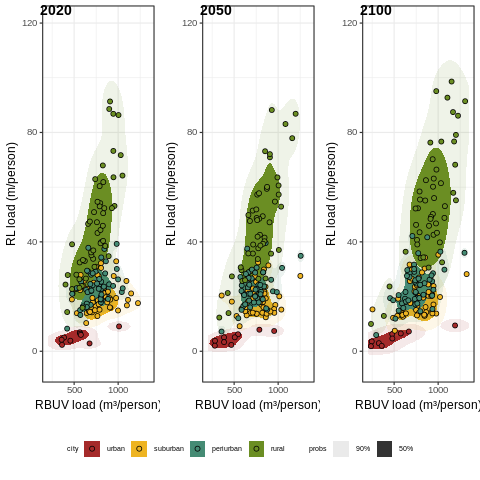

In [ ]:
%%R -i csv_dir -i fig_dir

# =========================
# LIBRARIES
# =========================
install.packages(c("tidyverse", "ggdensity", "cowplot", "tidyquant"), quiet=TRUE)

library(tidyverse)
library(ggdensity)
library(cowplot)
library(tidyquant)

par(family = "Arial")
# =========================
# FUNCTION
# =========================
plot_density <- function(df, X, Y, GROUP, xlim, ylim) {

  ggplot(df, aes(
    x = .data[[X]],
    y = .data[[Y]],
    fill = .data[[GROUP]]
  )) +

    geom_hdr(probs = c(0.9, 0.5)) +
    geom_point(shape = 21, size = 2) +

    scale_fill_manual(values = c(
      "brown", "goldenrod2", "aquamarine4", "olivedrab"
    )) +

    theme_bw(base_size = 12) +

    scale_x_continuous("RBUV load (m³/person)", limits = xlim) +
    scale_y_continuous("RL load (m/person)", limits = ylim)
}

# =========================
# SAFE LOADER FUNCTION
# =========================
load_data <- function(file) {
  df <- read.csv(file)

  df$city <- factor(
    if("city.type" %in% names(df)) df$city.type else df$citytype_at_2050,
    levels = c("urban","suburban","periurban","rural")
  )

  df[order(df$city), ]
}

# =========================
# FILES
# =========================
f1 <- file.path(csv_dir, "df_grouped_ssp2_1.csv")
f2 <- file.path(csv_dir, "df_grouped2_ssp2_1.csv")
f3 <- file.path(csv_dir, "df_grouped3_ssp2_1.csv")

d1 <- load_data(f1)
d2 <- load_data(f2)
d3 <- load_data(f3)

# =========================
# PLOTS
# =========================
p1 <- plot_density(d1, "volume_m3_perCap_2020", "length_m_perCap_2020", "city", c(200,1350), c(-5,120))
p2 <- plot_density(d2, "volume_m3_perCap_2050", "length_m_perCap_2050", "city", c(200,1350), c(-5,120))
p3 <- plot_density(d3, "volume_m3_perCap_2100", "length_m_perCap_2100", "city", c(200,1350), c(-5,120))

# =========================
# COMBINE
# =========================
prow <- plot_grid(
  p1 + theme(legend.position="none"),
  p2 + theme(legend.position="none"),
  p3 + theme(legend.position="none"),
  labels = c(" 2020"," 2050"," 2100"),
  align = 'vh',
  hjust = -1,
  nrow = 1
)

legend <- get_legend(
  p1 + theme(
    legend.position = "bottom",
    legend.text = element_text(size = 7),
    legend.title = element_text(size = 7)
  )
)

final_plot <- plot_grid(prow, legend, ncol=1, rel_heights=c(1,0.15))

print(final_plot)

# =========================
# SAVE
# =========================
ggsave(
  filename = file.path(fig_dir, "temporal_density_plot_below_10000.png"),
  plot = final_plot,
  width = 12,
  height = 5,
  dpi = 300
)

In addition: Warning messages:
1: Removed 1 row containing non-finite outside the scale range (`stat_hdr()`). 
2: Removed 1 row containing missing values or values outside the scale range
(`geom_point()`). 
3: Removed 1 row containing non-finite outside the scale range (`stat_hdr()`). 
4: Removed 1 row containing missing values or values outside the scale range
(`geom_point()`). 


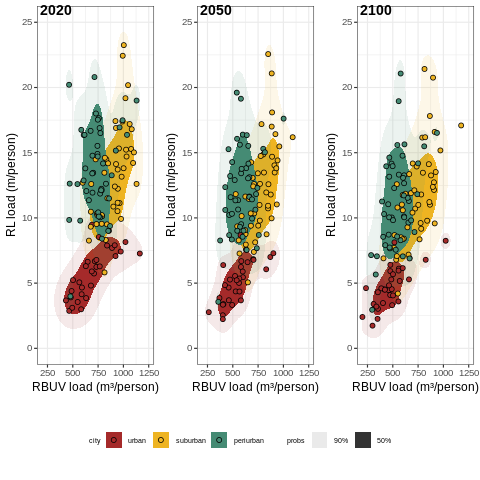

In [ ]:
%%R -i csv_dir -i fig_dir

# =========================
# LIBRARIES
# =========================
install.packages(c("tidyverse", "ggdensity", "cowplot", "tidyquant"), quiet=TRUE)

library(tidyverse)
library(ggdensity)
library(cowplot)
library(tidyquant)

# =========================
# FUNCTION
# =========================
plot_density <- function(df, X, Y, GROUP, xlim, ylim) {

  ggplot(df, aes(
    x = .data[[X]],
    y = .data[[Y]],
    fill = .data[[GROUP]]
  )) +

    geom_hdr(probs = c(0.9, 0.5)) +
    geom_point(shape = 21, size = 2) +

    scale_fill_manual(values = c(
      "brown", "goldenrod2", "aquamarine4", "olivedrab"
    )) +

    theme_bw(base_size = 12) +
    scale_x_continuous("RBUV load (m³/person)", limits = xlim) +
    scale_y_continuous("RL load (m/person)", limits = ylim)
    # scale_x_continuous("Per capita residential volume (m³)", limits = xlim) +
    # scale_y_continuous("Per capita roadway length (m)", limits = ylim)
}

# =========================
# SAFE LOADER FUNCTION
# =========================
load_data <- function(file) {
  df <- read.csv(file)

  df$city <- factor(
    if("city.type" %in% names(df)) df$city.type else df$citytype_at_2050,
    levels = c("urban","suburban","periurban","rural")
  )

  df[order(df$city), ]
}

# =========================
# FILES
# =========================
f1 <- file.path(csv_dir, "df_grouped_ssp2_2.csv")
f2 <- file.path(csv_dir, "df_grouped2_ssp2_2.csv")
f3 <- file.path(csv_dir, "df_grouped3_ssp2_2.csv")

d1 <- load_data(f1)
d2 <- load_data(f2)
d3 <- load_data(f3)

# =========================
# PLOTS
# =========================
p1 <- plot_density(d1, "volume_m3_perCap_2020", "length_m_perCap_2020", "city", c(200,1250), c(0,25))
p2 <- plot_density(d2, "volume_m3_perCap_2050", "length_m_perCap_2050", "city", c(200,1250), c(0, 25))
p3 <- plot_density(d3, "volume_m3_perCap_2100", "length_m_perCap_2100", "city", c(200,1250), c(0, 25))

# =========================
# COMBINE
# =========================
prow <- plot_grid(
  p1 + theme(legend.position="none"),
  p2 + theme(legend.position="none"),
  p3 + theme(legend.position="none"),
  align = 'vh',
  labels = c(" 2020", " 2050", " 2100"),
  hjust = -1,
  nrow = 1
)

legend <- get_legend(
  p1 + theme(
    legend.position = "bottom",
    legend.text = element_text(size = 7),
    legend.title = element_text(size = 7)
  )
)

final_plot <- plot_grid(prow, legend, ncol=1, rel_heights=c(1,0.2))

print(final_plot)

# =========================
# SAVE
# =========================
ggsave(
  filename = file.path(fig_dir, "temporal_density_plot_above_10000.png"),
  plot = final_plot,
  width = 12,
  height = 5,
  dpi = 300
)